In [1]:
# feedback of experiment using csv data (pandas)

import pandas as pd

path = '/home/loai/Documents/code/RSMLExtraction/Results/Evaluation/results_per_plant_evaluator.csv'
df = pd.read_csv(path)
df

,model,split,status,metric,box,time,value
0,Segformer_bce_dice,Val,expertized,NumberOfOrgansRatio,230629PN006,1,1.000000
1,Segformer_bce_dice,Val,expertized,NumberOfOrgansRatio,230629PN006,1,1.000000
2,Segformer_bce_dice,Val,expertized,NumberOfOrgansRatio,230629PN006,1,1.000000
3,Segformer_bce_dice,Val,expertized,NumberOfOrgansRatio,230629PN006,1,1.000000
4,Segformer_bce_dice,Val,expertized,NumberOfOrgansRatio,230629PN006,1,1.000000
...,...,...,...,...,...,...,...
92911,Unet_bce_dice,Test,before_expertized,EuclidianDistancebtwIntercepts,230629PN024,29,36.715120
92912,Unet_bce_dice,Test,before_expertized,EuclidianDistancebtwIntercepts,230629PN024,29,88.164619
92913,Unet_bce_dice,Test,before_expertized,EuclidianDistancebtwIntercepts,230629PN024,29,36.755952
92914,Unet_bce_dice,Test,before_expertized,EuclidianDistancebtwIntercepts,230629PN024,29,29.017236


In [2]:
# get all unique models 
unique_models = df['model'].unique()
print("Unique models:", unique_models)

unique_boxes = df['box'].unique()
print("Unique boxes:", unique_boxes)

unique_metrics = df['metric'].unique()
print("Unique metrics:", unique_metrics)

Unique models: ['Segformer_bce_dice' 'Unet_bce' 'Segformer_bce' 'Unet_dice_cldice'
 'Unet_dice' 'Unet_bce_dice']
Unique boxes: ['230629PN006' '230629PN019' '230629PN014' '230629PN012' '230629PN031'
 '230629PN018' '230629PN010' '230629PN027' '230629PN008' '230629PN024']
Unique metrics: ['NumberOfOrgansRatio' 'TotalRootLengthRatio' 'Area_convex_HullRatio'
 'AreaBetweenIntercepts' 'DTWBetweenIntercepts'
 'EuclidianDistancebtwIntercepts']


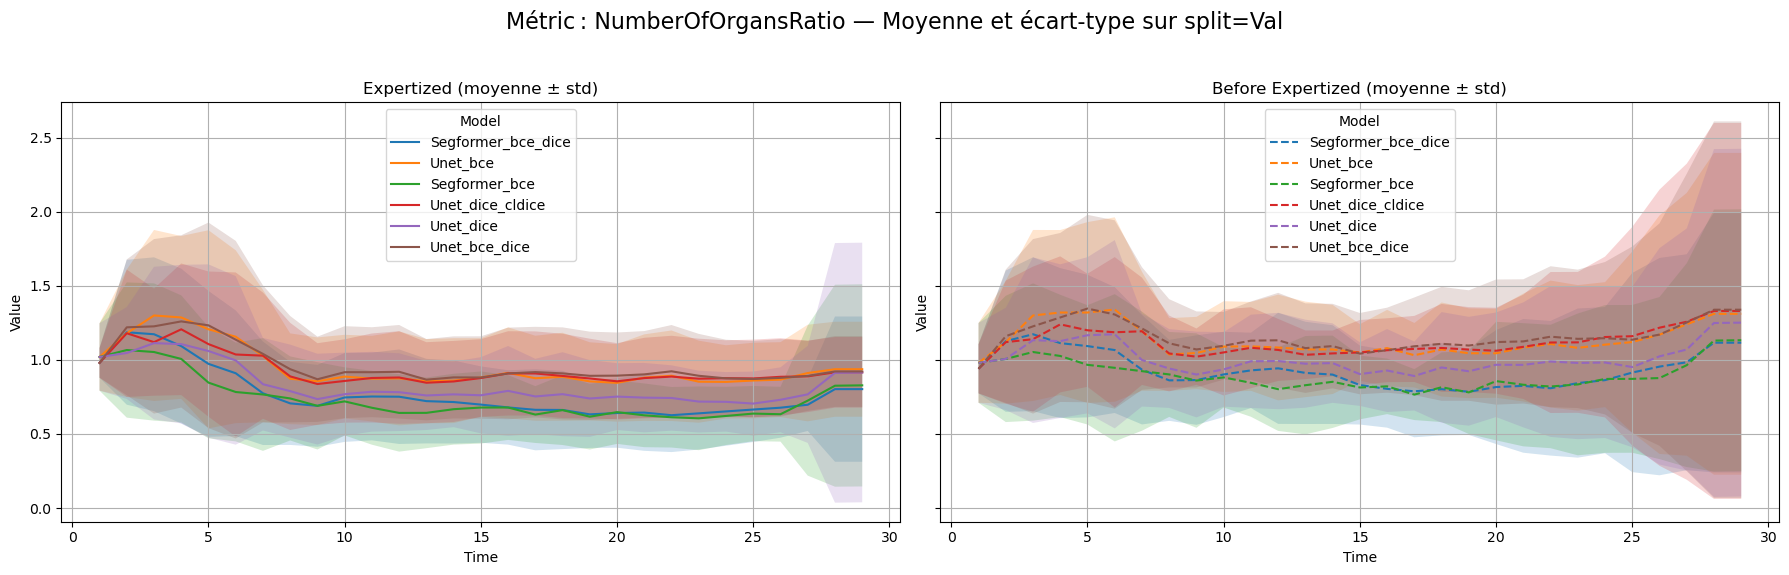

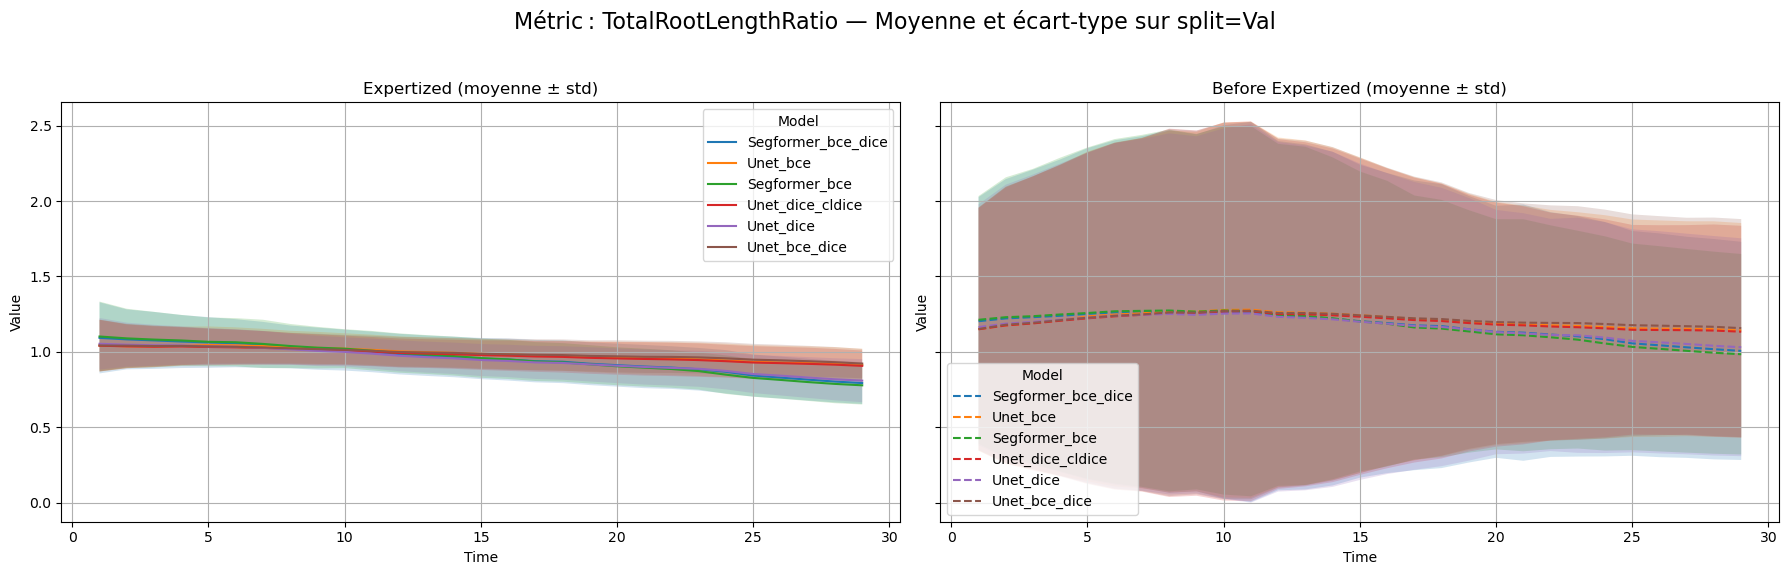

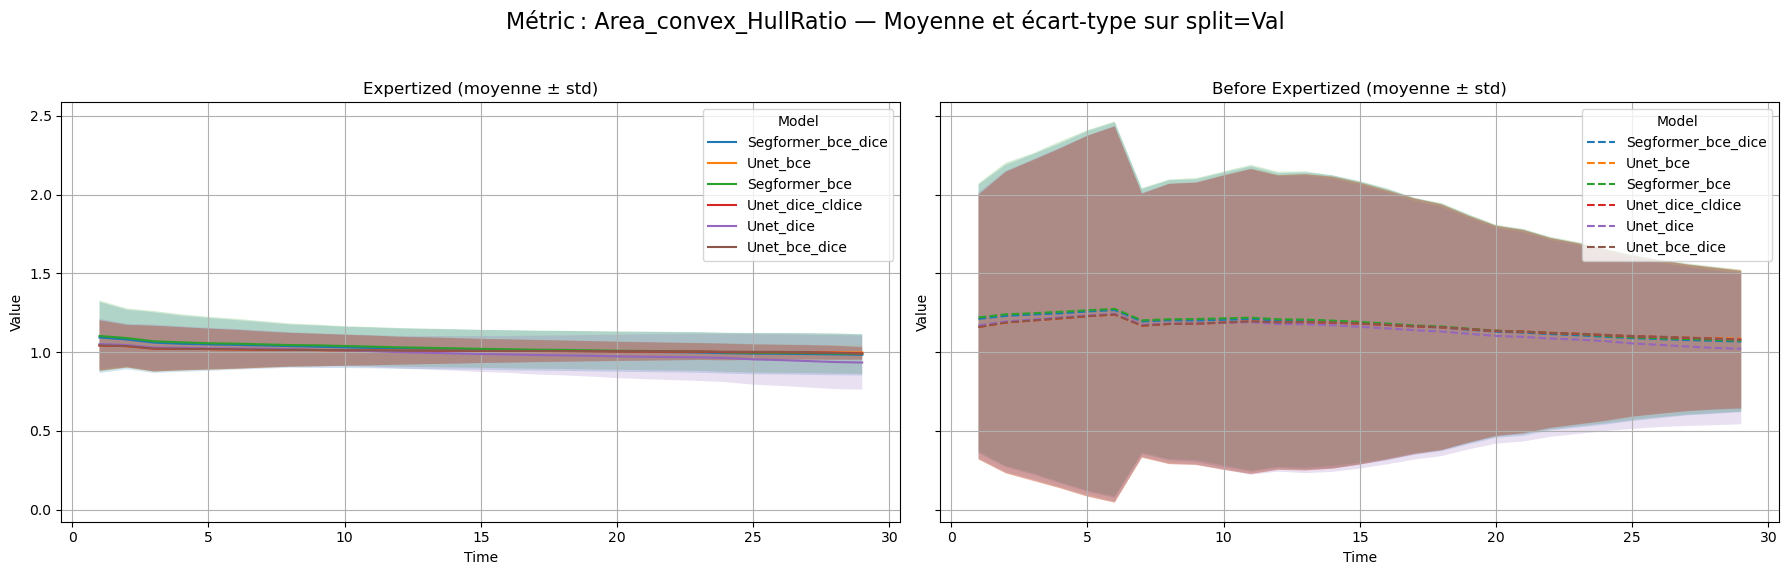

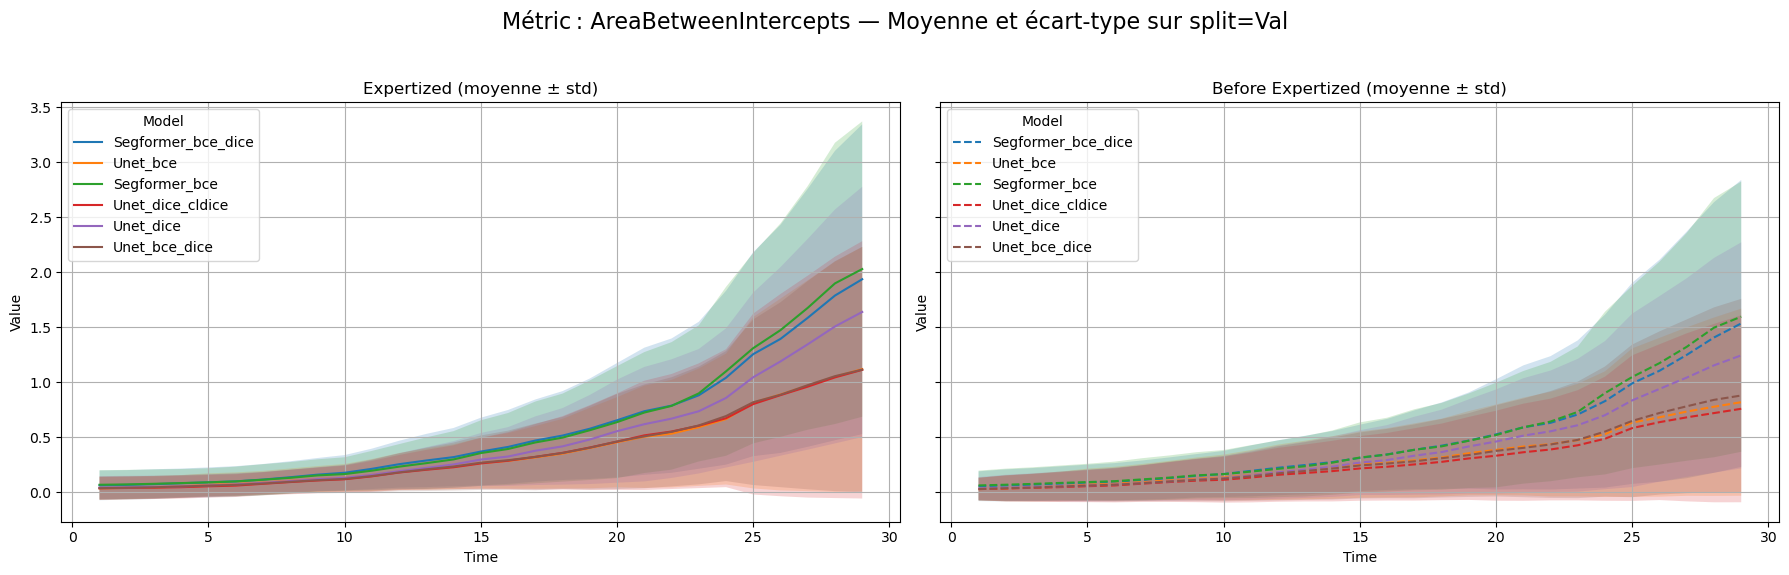

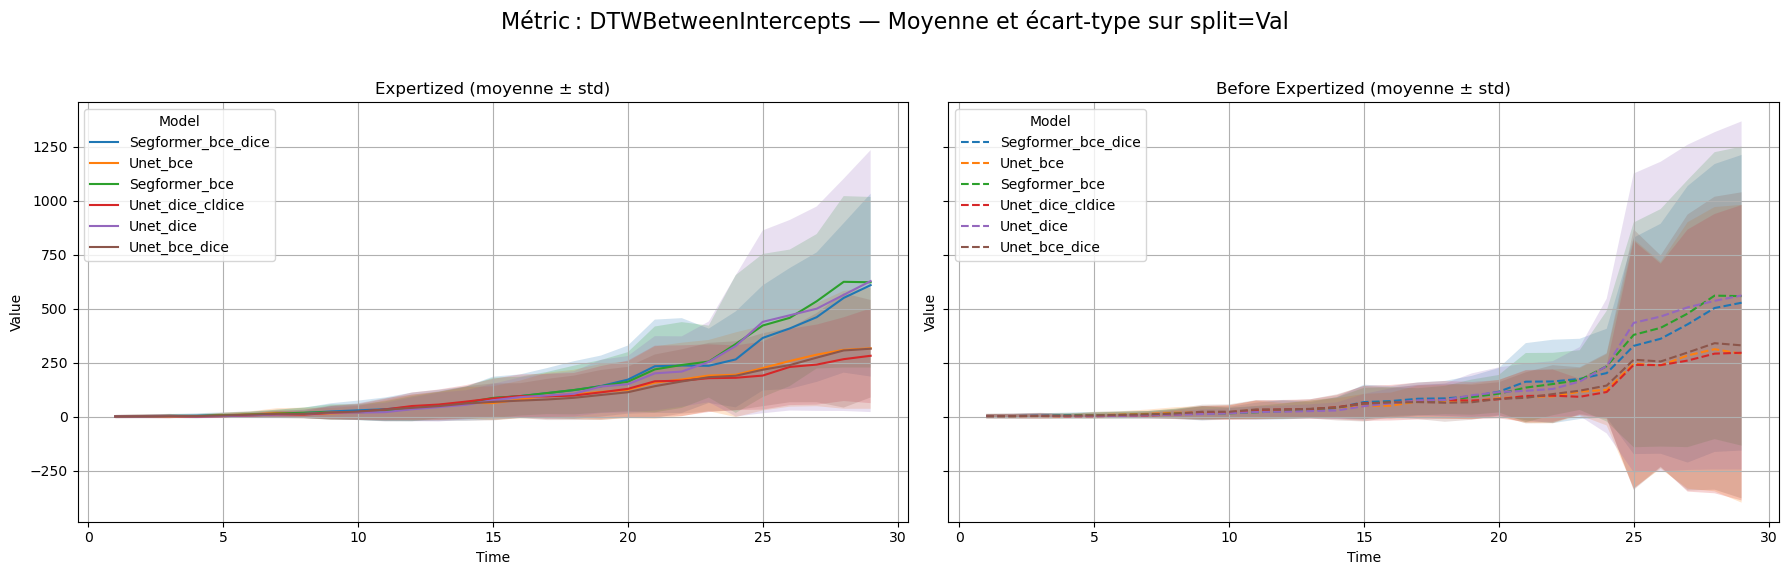

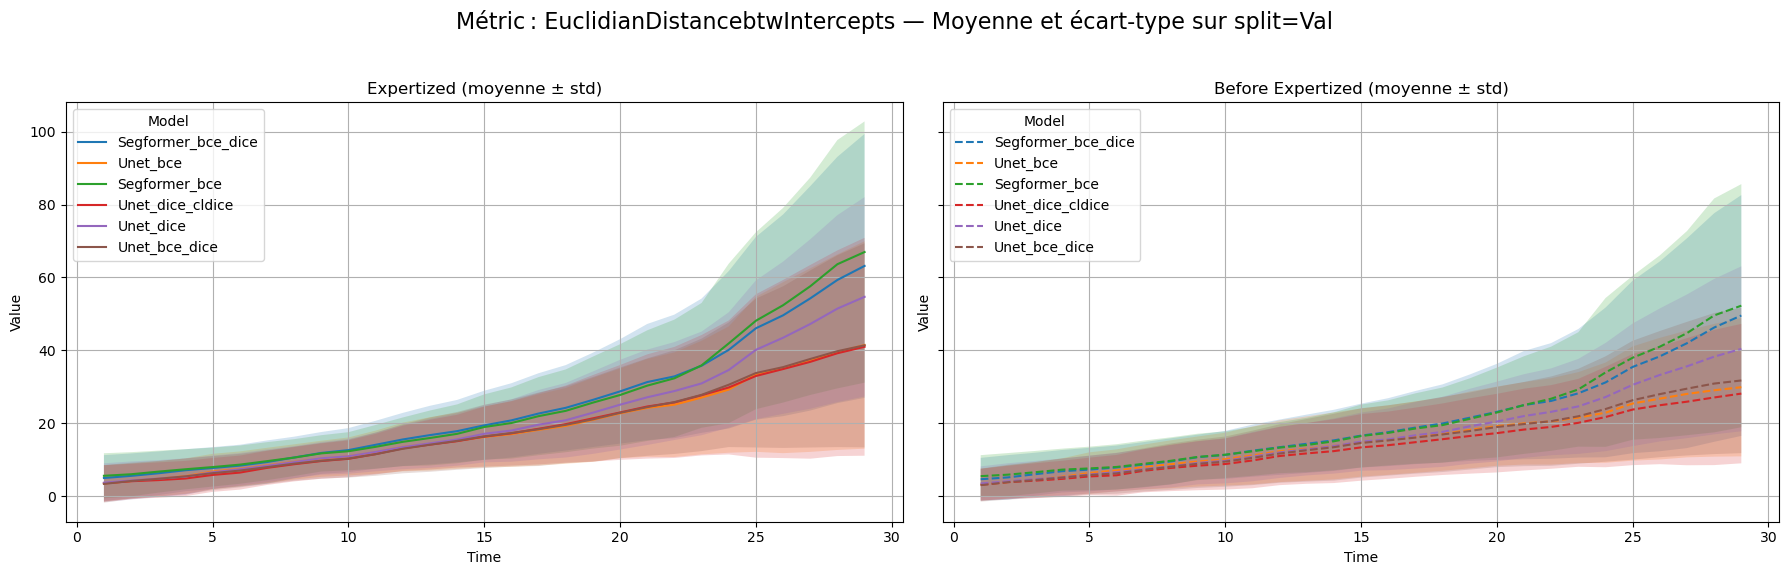

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# 0. Filtrer sur split = 'Val'
df_val = df[df['split'] == 'Val']

# 1. Calculer la moyenne et l'écart‑type across boxes
df_stats = (
    df_val
    .groupby(['model', 'metric', 'status', 'time'], as_index=False)['value']
    .agg(mean='mean', std='std')
)

# 2. Boucler sur chaque metric pour tracer mean ± std
for metric in unique_metrics:
    fig, (ax_e, ax_b) = plt.subplots(
        nrows=1, ncols=2, figsize=(18, 6), sharey=True
    )
    
    df_m = df_stats[df_stats['metric'] == metric]
    
    for model in unique_models:
        # Extraire mean et std pour chaque statut
        for ax, status, title, linestyle in [
            (ax_e, 'expertized', 'Expertized', '-'),
            (ax_b, 'before_expertized', 'Before Expertized', '--')
        ]:
            df_ms = df_m[
                (df_m['model'] == model) &
                (df_m['status'] == status)
            ].sort_values('time')
            
            # Séries
            times = df_ms['time']
            means = df_ms['mean']
            stds  = df_ms['std'].fillna(0)  # éviter NaN si une seule box
            
            # Tracer la moyenne
            ax.plot(times, means, label=model, linestyle=linestyle)
            # Bande d'écart‑type
            ax.fill_between(
                times,
                means - stds,
                means + stds,
                alpha=0.2
            )
    
    # Mise en forme
    ax_e.set_title('Expertized (moyenne ± std)')
    ax_b.set_title('Before Expertized (moyenne ± std)')
    for ax in (ax_e, ax_b):
        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.legend(title='Model')
        ax.grid(True)
    
    fig.suptitle(f'Métric : {metric} — Moyenne et écart-type sur split=Val', fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from ipywidgets import interact, IntSlider

# 0. Filtrer sur split = 'Val'
df_val = df[df['split'] == 'Val']

# Liste des boxes
unique_boxes = sorted(df_val['box'].unique())

def plot_for_box(box_idx):
    box = unique_boxes[box_idx]
    df_box = df_val[df_val['box'] == box]

    # Calculer la moyenne par model/metric/status/time
    df_stats = (
        df_box
        .groupby(['model', 'metric', 'status', 'time'], as_index=False)['value']
        .mean()
        .rename(columns={'value': 'mean'})
    )

    # Pour chaque metric, deux subplots côte à côte
    for metric in unique_metrics:
        fig, (ax_e, ax_b) = plt.subplots(
            nrows=1, ncols=2, figsize=(14, 5), sharey=True
        )
        df_m = df_stats[df_stats['metric'] == metric]

        for model in unique_models:
            # expertized
            df_e = df_m[(df_m['model']==model) & (df_m['status']=='expertized')] \
                   .sort_values('time')
            ax_e.plot(df_e['time'], df_e['mean'], label=model)

            # before_expertized
            df_b = df_m[(df_m['model']==model) & (df_m['status']=='before_expertized')] \
                   .sort_values('time')
            ax_b.plot(df_b['time'], df_b['mean'], linestyle='--', label=model)

        ax_e.set_title(f'Box={box} — Expertized')
        ax_b.set_title(f'Box={box} — Before Expertized')
        for ax in (ax_e, ax_b):
            ax.set_xlabel('Time')
            ax.set_ylabel('Value')
            ax.legend(title='Model')
            ax.grid(True)

        fig.suptitle(f'Metric : {metric}', fontsize=16)
        fig.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Slider pour naviguer entre les boxes
interact(
    plot_for_box,
    box_idx=IntSlider(
        min=0,
        max=len(unique_boxes)-1,
        step=1,
        value=0,
        description='Box index'
    )
);


interactive(children=(IntSlider(value=0, description='Box index', max=4), Output()), _dom_classes=('widget-int…

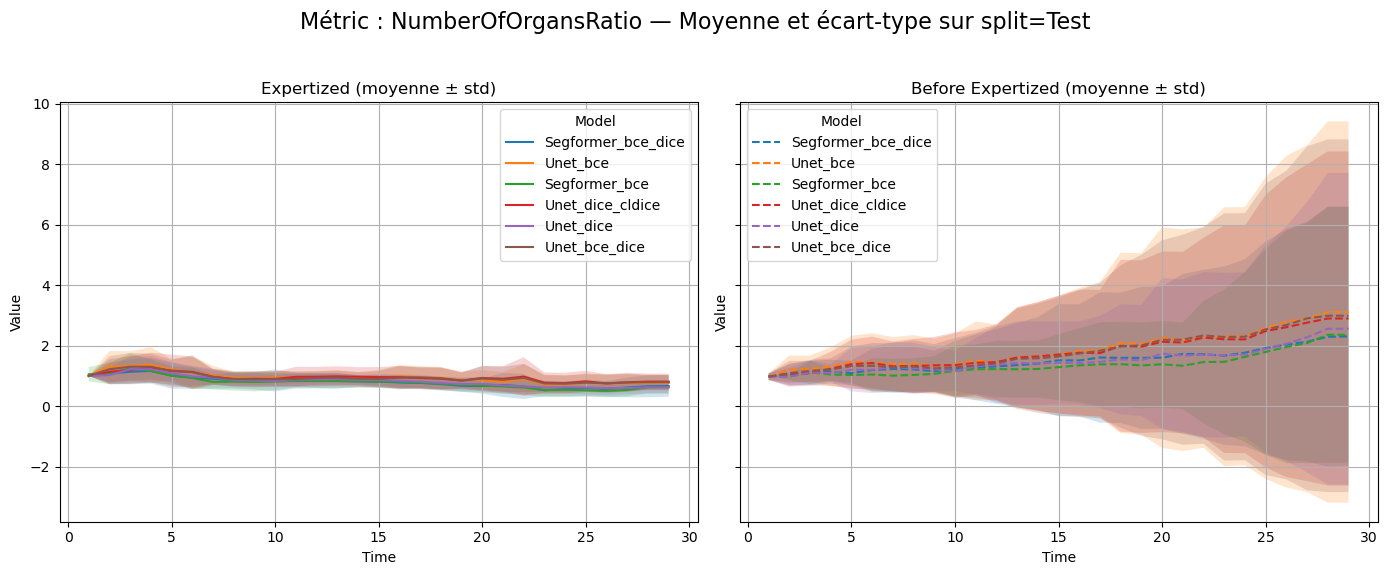

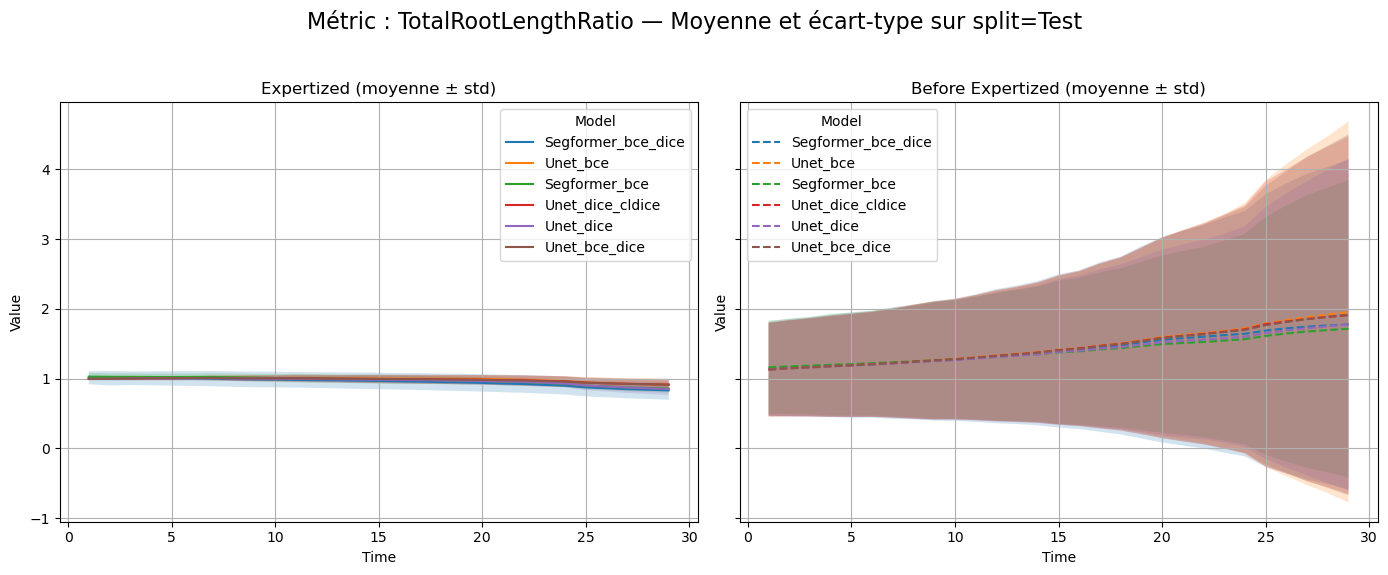

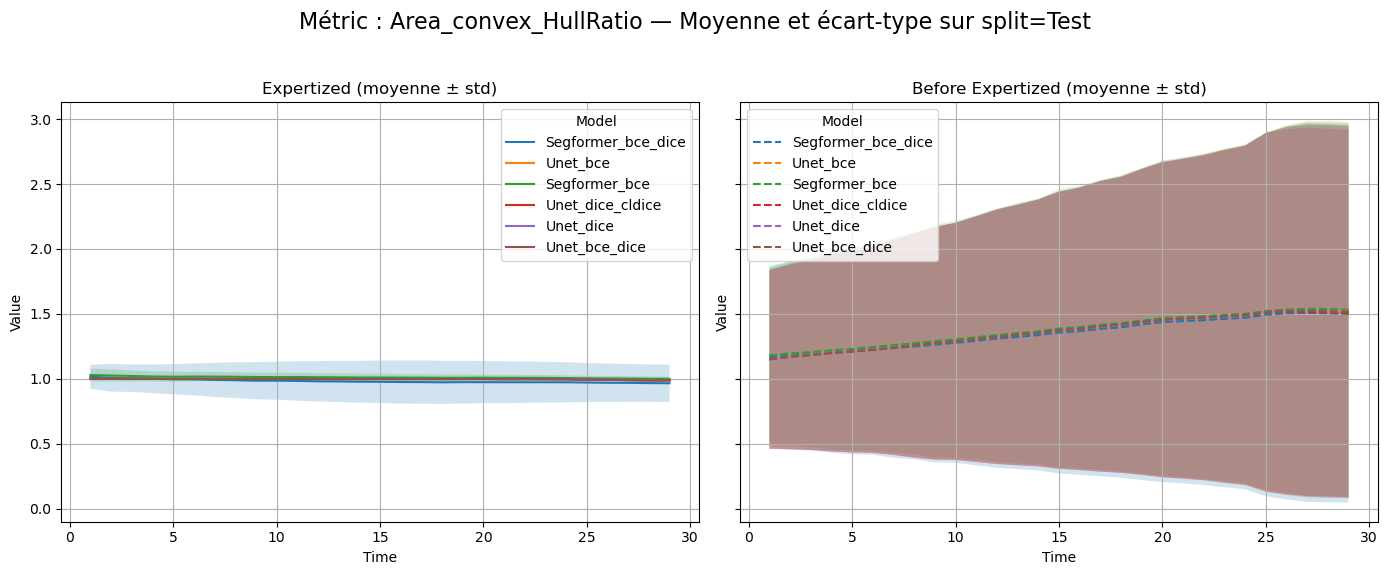

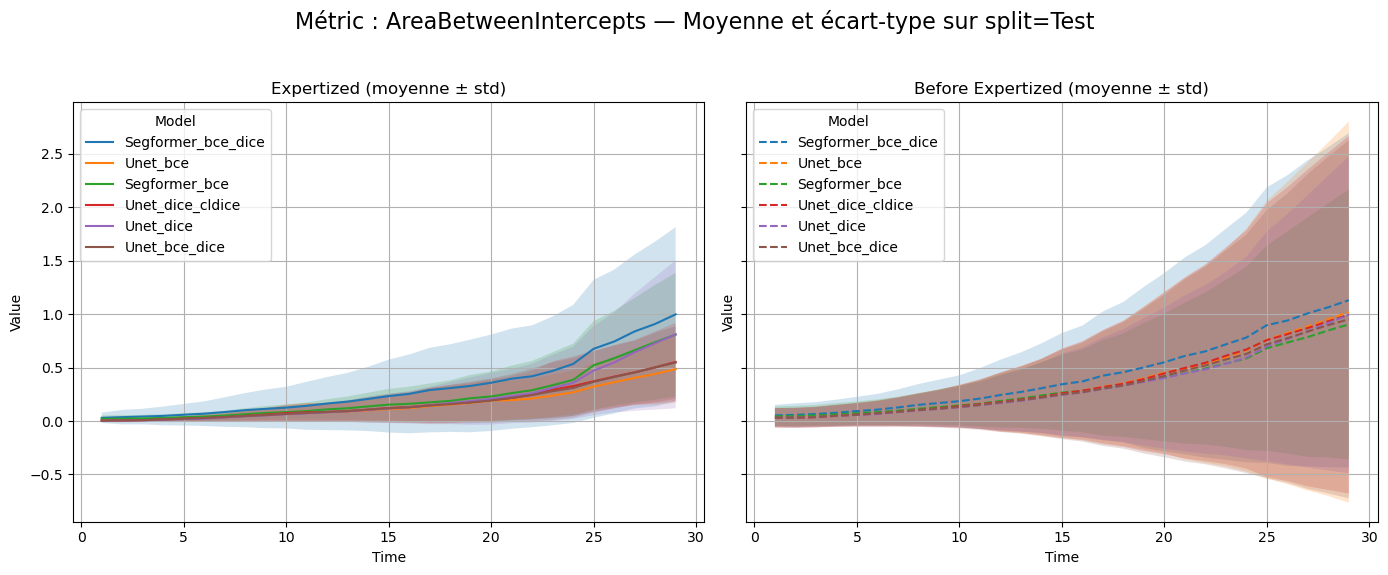

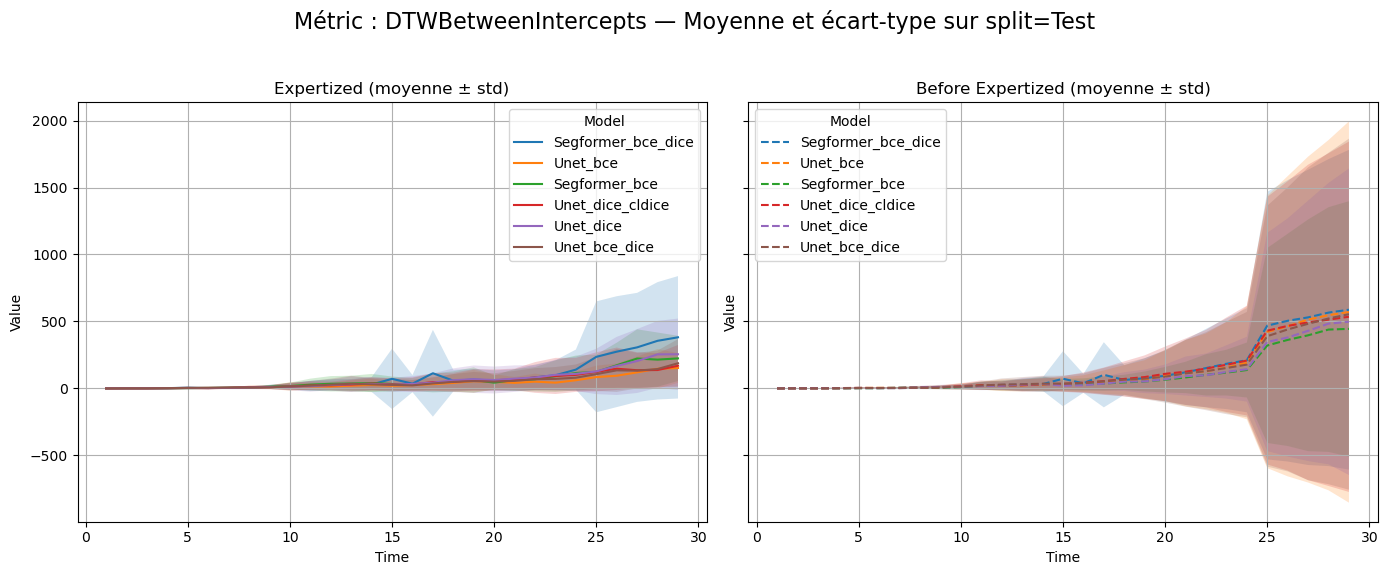

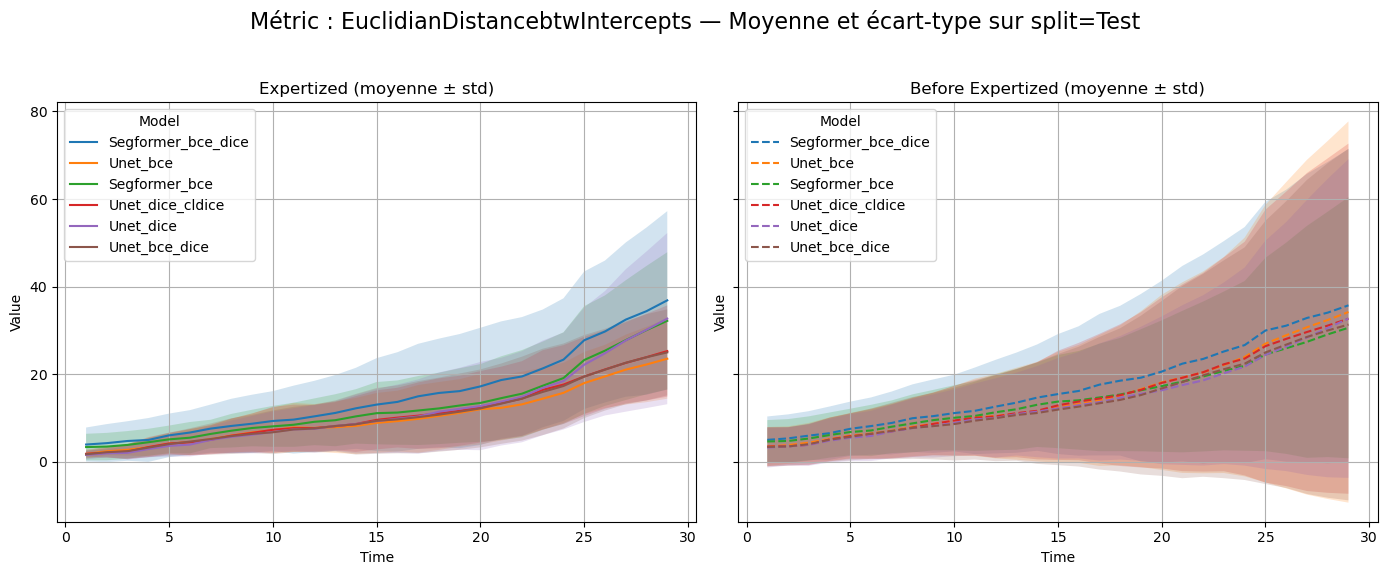

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# 0. Filtrer sur split = 'test'
df_val = df[df['split'] == 'Test']

# 1. Calculer la moyenne et l'écart‑type across boxes
df_stats = (
    df_val
    .groupby(['model', 'metric', 'status', 'time'], as_index=False)['value']
    .agg(mean='mean', std='std')
)

# 2. Boucler sur chaque metric pour tracer mean ± std
for metric in unique_metrics:
    fig, (ax_e, ax_b) = plt.subplots(
        nrows=1, ncols=2, figsize=(14, 6), sharey=True
    )
    
    df_m = df_stats[df_stats['metric'] == metric]
    
    for model in unique_models:
        # Extraire mean et std pour chaque statut
        for ax, status, title, linestyle in [
            (ax_e, 'expertized', 'Expertized', '-'),
            (ax_b, 'before_expertized', 'Before Expertized', '--')
        ]:
            df_ms = df_m[
                (df_m['model'] == model) &
                (df_m['status'] == status)
            ].sort_values('time')
            
            # Séries
            times = df_ms['time']
            means = df_ms['mean']
            stds  = df_ms['std'].fillna(0)  # éviter NaN si une seule box
            
            # Tracer la moyenne
            ax.plot(times, means, label=model, linestyle=linestyle)
            # Bande d'écart‑type
            ax.fill_between(
                times,
                means - stds,
                means + stds,
                alpha=0.2
            )
    
    # Mise en forme
    ax_e.set_title('Expertized (moyenne ± std)')
    ax_b.set_title('Before Expertized (moyenne ± std)')
    for ax in (ax_e, ax_b):
        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.legend(title='Model')
        ax.grid(True)
    
    fig.suptitle(f'Métric : {metric} — Moyenne et écart-type sur split=Test', fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
